### ***`The final project (Temperature Regression) `***

Author: Preston, Luobin, Luyi

Task Description:
In this project, we will build a linear regression model to predict the temperature at
various weather stations across Sweden. We use data provided by the Swedish Me
teorological and Hydrological Institute (SMHI), which includes temperature readings,
coordinates, and elevation for a large number of stations. The goal is to use this data
to predict the temperature at locations where it has not been recorded.
The file temperature_data.csv contains the necessary data for this project. Each row
corresponds to a weather station, with columns for the station id and name, its longitude,
latitude and elevation (meters above sea level), and the temperature (◦C) recorded there
at 16:00 5/12-2025. Temperature measurements are missing for some of the stations;
your task is to predict these missing values.

The overall goal is to implement a simple temperature regression model.

### Task 1:
We will use a linear regression model for the temperature. To get a feel for how
this works, you should first consider temperature as a function of only longitude.
Select a few stations and plot their temperature against their longitude. Try and
find the straight line which fits this data best. It’s not a bad idea to do this with
a ruler on paper first!

### Task 2:
We can use calculus to find the optimal line ax +b, by determining which a and b
minimize the squared error

$\sum\limits_{i=1}^{n} (y_i - ax_i - b)^2,$

where yi are the temperature values and xi the spatial coordinates of the measure
ment unit (in this case only longitude). Compute the optimal parameters a and b
for the data points you selected in Task 1.

In [7]:
import os
import csv
import urllib.request
import numpy as np
import matplotlib
from numpy import array
from matplotlib import pyplot as plt

filename = 'temperature_data.csv'
url = "https://raw.githubusercontent.com/luyihappy/The-final-project-of-python-course/refs/heads/main/temperature_data.csv"

if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)

# create empty variable lists
temp = []
long = []
lat = []
elev = []
id = []
name = []

#extract data using csv library, more basic than pandas approach we use in chem courses
with open('temperature_data.csv', 'r') as file:
    # create csv reader obj
    csv_reader = csv.reader(file)
    # skip header
    next(csv_reader)
    # read each column and add values to the variable lists as float or int
    for row in csv_reader:
        # each variable's column in csv is read using row[x] to extract the values for each row in file
        # empty temp values are caught with ValueError before reading other columns
        # if no temp value exists for the row then the row is not recorded to any of the other variable lists
        # this prevents misalignment when indexing the variable lists
        try:
            current_temp = float(row[5])
        except ValueError:
            continue

        id.append(int(row[0]))
        name.append(str(row[1]))
        lat.append(float(row[2]))
        long.append(float(row[3]))
        elev.append(float(row[4]))
        temp.append(current_temp)

# Method 1 Calculus (Luyi)
print(f'Task 2:')
print(f'Outcome of method 1:')
def squared_error(x,y,a,b):
    error_sum=0
    for i in range(len(y)):
        error_sum=error_sum+(y[i]-a*x[i]-b)**2
    return error_sum
def derivative_a(f,x,y,a,b,h=10e-6):
    return (f(x,y,a+h,b)-f(x,y,a,b))/h
def derivative_b(f,x,y,a,b,h=10e-6):
    return (f(x,y,a,b+h)-f(x,y,a,b))/h
def gradient(x,y,a,b):
    return (derivative_a(squared_error,x,y,a,b),derivative_b(squared_error,x,y,a,b))
# Gradient descent algorithm:
# Start point
a=100
b=3
# Learning rate alpha controls the size of the steps. If too large, it will result
# in exploding gradients (not convergent outcome).
alpha=0.00001
df_a,df_b=gradient(long,temp,a,b)
for i in range(1000000):
    a=a-alpha*df_a
    b=b-alpha*df_b
    df_a,df_b=gradient(long,temp,a,b)
    if abs(df_a)<=0.001 and abs(df_b)<=0.001:
        print(f'slope={a},\n y-intercept={b}')
        print(f'gradient={gradient(long,temp,a,b)}')
        break
print(f'squared error={squared_error(long,temp,a,b)}')


Task 2:
Outcome of method 1:
slope=-0.7441757991869054,
 y-intercept=12.750566370316392
gradient=(5.798028723802417e-05, -0.0009998984751291573)
squared error=2269.296295180671


In [8]:
# Method 2_Statistics (Preston and Luobin)
print(f'Outcome of method 2:')
def lin_fit(x, y):
    # calculate mean values for x, y input variables
    mean_x = sum(x) / len(x)
    mean_y = sum(y) / len(y)
    # create numerator and denominator variables to be added to in loop
    numer = 0
    denom = 0
    # loops for each item in the variable list. len() only gives an int so range() is needed
    for i in range(len(x)):
        # range() starts at 0 so index doesn't need to be [i-1]
        diff_x = x[i] - mean_x
        diff_y = y[i] - mean_y
        # sum numerator and denominator over i loops
        numer += diff_x * diff_y
        denom += diff_x ** 2

    # calculate slope and intercept using calculated values from loop
    slope = numer / denom
    y_int = mean_y - (slope * mean_x)

    return [slope, y_int]


def get_rsquared(slope, y_int, x_data, y_data):
    # calculate 'sum of squared errors' for x, y variables with given slope and intercept
    # get mean_y for total error calculation
    mean_y = sum(y_data) / len(y_data)
    # create error sum variables
    sum_residual_err = 0.0
    sum_total_err = 0.0
    # sum errors for each data point
    for i in range(len(x_data)):
        predicted = y_int + (slope * x_data[i])
        # sum differences between predicted and actual y values 'model error'
        sum_residual_err += (y_data[i] - predicted) ** 2
        # sum differences between mean and y values 'baseline error' or 'total sum of squares'
        sum_total_err += (y_data[i] - mean_y) ** 2
    return 1 - (sum_residual_err / sum_total_err)

# test functions
ax_b = lin_fit(long, temp)
print('slope =',ax_b[0])
print('y-intercept =',ax_b[1])
sqr_test = get_rsquared(ax_b[0], ax_b[1], long, temp)
print('R^2:', sqr_test)



Outcome of method 2:
slope = -0.7440357821602769
y-intercept = 12.748237545625273
R^2: 0.22354173638616415


### Task 3:
Any data modeling project should start by looking at the data. Load the entire
data set and visualize it using appropriate plots. What trends do you see?

In [9]:
# TASK 3 (Preston) -------------------------------------------------------------
# trendline data table
plot_names= ['longitude','latitude','elevation']
plot_slopes = [-0.744,-1.21,-0.0155]
plot_inters = [12.7, 74.6, 3.2]
plot_rsquareds = [0.224, 0.858, 0.414]
# print header
print('\n')
print(f"{'Variable':<12} | {'Slope':<8} | {'Intercept':<10} | {'R-squared':<9}")
print("-" * 50)
# combine and loop through the data using zip()
for name, slope, inter, rsq in zip(plot_names, plot_slopes, plot_inters, plot_rsquareds):
    print(f"{name:<12} | {slope:<8} | {inter:<10} | {rsq:<9}")





Variable     | Slope    | Intercept  | R-squared
--------------------------------------------------
longitude    | -0.744   | 12.7       | 0.224    
latitude     | -1.21    | 74.6       | 0.858    
elevation    | -0.0155  | 3.2        | 0.414    


### Task 4:
The full model we will use is an extension of the simple best-fit line used in Task
2. We will use a linear model of the form
$$y_i = \beta_0 + \beta_1 x_i^{lat} + \beta_2 x_i^{lon} + \beta_3 x_i^{elev}, \quad i=1, ..., n$$
where yi is the temperature at station i, and xlat
i = 1,...,n
i , xlon
i
, and xelev
are the corre
sponding latitude, longitude, and elevation. βj,j = 0,...,3 are the parameters of
the model. Write this model in a matrix-vector form.


In [10]:
# TASK 4 (Preston) -------------------------------------------------------------

# matrix for three input variables to perform regression on
matrix = [lat, elev, long]
# create empty multiple linear regression variables
multi_y_int = 0.0
# len() allows for changing number of matrix variables
multi_slopes = [0.0] * len(matrix)

# number of loops to optimize regressions
iter = 42

for i in range(iter):
    # loops over iterations to refine the slope and intercept for multiple lin reg
    for var in range(len(matrix)):
        # var specifies which of the variables in the matrix will be used for lin reg
        # while other two variables are fixed
        # empty list for predicted y values resulting from the slopes of the fixed variables
        # slopes start at 0.0 in first loop
        fixed_y = []
        for t in range(len(temp)):
            # calculates slope of all fixed variables' impact on temperature for each data point t
            # applies only to variables that are fixed by excluding the unfixed var from outer loop: "if fixed != var"
            fixed_var_impact = sum(multi_slopes[fixed] * matrix[fixed][t] for fixed in range(len(matrix)) if fixed != var)
            # appends reduced y values to list to perform linear regression on with unfixed variable 'var'
            fixed_y.append(temp[t] - fixed_var_impact)

        # perform linear flit on unfixed variable
        new_slope, new_int = lin_fit(matrix[var], fixed_y)
        # update slope for unfixed variable
        multi_slopes[var] = new_slope
        # intercept simply optimizes as each loop is executed, with enough iterations the final loops have
        # slopes that are nearly constant, meaning the intercept is representative of the optimized
        # multiple regression process
        multi_int = new_int

# print caclulated values
print('Slopes:',multi_slopes)
print('y-intercept:',multi_int)

# test predictions
multi_predicted = []
for i in range(len(temp)):
    total_prediction = multi_int + sum(multi_slopes[var] * matrix[var][i] for var in range(len(matrix)))
    multi_predicted.append(total_prediction)

r_squared = get_rsquared(slope = 1.0, y_int = 0.0, x_data = multi_predicted, y_data = temp)
print('multi linear regression R^2:', r_squared)



Slopes: [-1.1898406266733572, -0.00448270725360609, 0.1765282451379796]
y-intercept: 71.22361877907406
multi linear regression R^2: 0.9099771670301681


### Task 5:
To fit the model to ourdata, we want to find the model parameters $\beta = (\beta_0, \beta_1, \beta_2, \beta_3)^T$
that minimize the squared error between the predicted and observed temperatures.
This is the multidimensional generalization of the best fit line you derived in Task 2. The least squares estimator for β is given by
$$\beta = (\mathbf{X}^T \mathbf{X})^{-1} (X)^T \mathbf{Y}$$
where X is the matrix containing the spatial coordinates (latitude, longitude and
elevation) and Y is the vector containing the observed temperature measurements.
Compute this estimator using the entire data set! How can you use it to predict
the temperature at new locations when the latitude, longitude, and elevation are
known? Interpret the four parameters! What makes β0 different from the rest?

In [11]:
# TASK 4 and 5 (Luobin)
x_lat = np.array(lat)
x_long = np.array(long)
x_elev = np.array(elev)
one = np.ones(len(x_lat))

y = np.array(temp)
matrix = np.array([one, x_lat, x_long, x_elev])
matrix_T = matrix.T

def model(matrix_T,beta):
    return matrix_T @ beta

beta = np.linalg.inv(matrix @ matrix.T) @ matrix @ y #beta = np.array([B_0, B_1, B_2, B_3])
B_0 = beta[0]
B_1 = beta[1]
B_2 = beta[2]
B_3 = beta[3]

print(f'Beta 0 is intercept: {B_0:.4f}')
print(f'Beta 1 is slope of latitude: {B_1:.4f}')
print(f'Beta 2 is slope of longtitude: {B_2:.4f}')
print(f'Beta 3 is slope of elevation: {B_3:.4f}')



Beta 0 is intercept: 71.2236
Beta 1 is slope of latitude: -1.1898
Beta 2 is slope of longtitude: 0.1765
Beta 3 is slope of elevation: -0.0045


### Task 6:
Evaluate the performance of your model. How well does it predict the temper
atures at the stations where we already know the temperature? A common way
to evaluate the performance of a regression model is to compute the root mean
squared error (RMSE) between the predicted and observed temperatures. What
does it tell you about the performance of your model? Can you see any patterns
in the prediction errors? It is a good idea to plot them in various ways, to get an
idea of how the model is performing and where it struggles.

Task 6
the coefficient of determination R^2= 0.9099771670301682
the root mean squared error is 1.4336987108726773


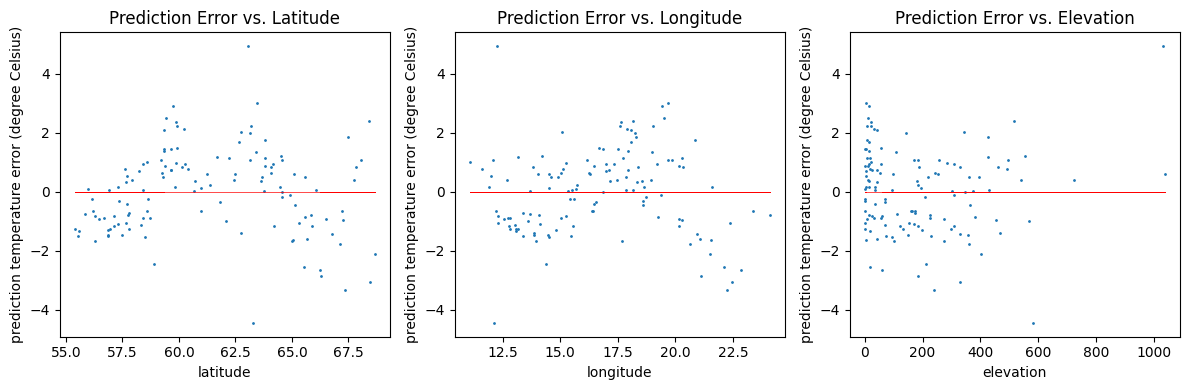

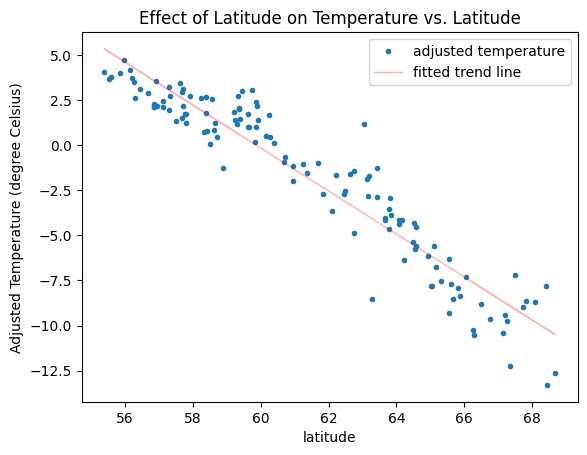

In [12]:
# Task 6 (Luyi)
print(f'Task 6')
# 1.Calculate the coefficient of determination R^2
# Using the multiplication of matrices between one containing
# spatial coordinates and the other the intercept and slopes
# to get the predicted temperature values
# Create a matrix containing spatial coordinates
# Creat one vector full of one so that could be used to multiply
# with the intercept
intercept_term_multiplier=np.ones(len(temp))
X_matrix_Transpose=array([intercept_term_multiplier,
                       lat,
                       long,
                       elev])
X_matrix=X_matrix_Transpose.T
# Create the matrix containing the intercept and slopes
b0=multi_int
b1,b3,b2=multi_slopes
b_matrix=array([b0,b1,b2,b3])
# Multiply two matrices to get the predicted temperature matrix
predicted_temp=X_matrix@b_matrix
pred_error=temp-predicted_temp
pred_error_squared=pred_error**2
pred_error_squared_sum=sum(pred_error_squared)
mean_temp=sum(temp)/len(temp)
deviation=array(temp)-mean_temp
deviation_squared=deviation**2
total_variation=sum(deviation_squared)
R_squared=1-pred_error_squared_sum/total_variation
print(f'the coefficient of determination R^2=',R_squared)


# 2.Calculate RMSE

# x1 denotes latitue variables, x2 denotes longtitude variables, x3 denotes elevation
# variables
pred_error_squared_mean=pred_error_squared.mean()
RMSE=pred_error_squared_mean**0.5

print(f'the root mean squared error is {RMSE}')

# 3.Plot prediction error/residual vs. three different variables
plt.figure(figsize=(12, 4))
# Create an array full of zeros to plot y=0 line
y=np.zeros(len(lat))
plt.subplot(131)
plt.plot(lat,pred_error,'.',markersize=2)
plt.plot(lat,y,color='red',linewidth=0.5)
plt.title('Prediction Error vs. Latitude')
plt.xlabel('latitude')
plt.ylabel('prediction temperature error (degree Celsius)')
plt.subplot(132)
plt.plot(long,pred_error,'.',markersize=2)
plt.plot(long,y,color='red',linewidth=0.5)
plt.title('Prediction Error vs. Longitude')
plt.xlabel('longitude')
plt.ylabel('prediction temperature error (degree Celsius)')
plt.subplot(133)
plt.plot(elev,pred_error,'.',markersize=2)
plt.plot(elev,y,color='red',linewidth=0.5)
plt.title('Prediction Error vs. Elevation')
plt.xlabel('elevation')
plt.ylabel('prediction temperature error (degree Celsius)')
plt.tight_layout()
plt.show()

#4. Plot adjusted temperature (partial residual+intercept)
# Take longitude as an example
part_lat=array(temp)-b2*array(long)-b3*array(elev)
plt.plot(lat,part_lat,'.',label='adjusted temperature')
fitted_line=b1*array(lat)+b0
plt.plot(lat,fitted_line,color='red',alpha=0.3,linewidth=1,label='fitted trend line')
plt.title('Effect of Latitude on Temperature vs. Latitude')
plt.xlabel('latitude')
plt.ylabel('Adjusted Temperature (degree Celsius)')
plt.legend()
plt.show()



### Task 7:
Now that you have a fitted model, you can use it to predict the temperature at
the location with missing data. Make these predictions and present them in your
final presentation. Note, in your oral presentation you can present this as a real
weather program!

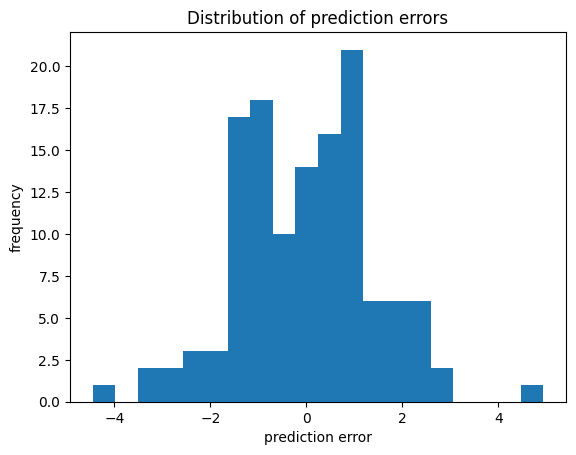

In [13]:
# TASK 7 (Luobin) ---------------------------------------------------------------
with open('temperature_data.csv', mode='r', encoding='utf-8') as input, \
     open('predicted_temperature_data.csv', mode='w', encoding='utf-8',newline='') as output:
     csv_reader = csv.reader(input)
     csv_writer = csv.writer(output)

     header = next(csv_reader)
     header.append('predicted temperature')
     csv_writer.writerow(header)

     for row in csv_reader:
            lat = (float(row[2]))
            long = (float(row[3]))
            elev = (float(row[4]))
            temp_pre = B_0 + B_1 * lat + B_2 * long + B_3 * elev
            row.append(round(temp_pre,1))
            csv_writer.writerow(row)

# Task 7 (Luyi)
# Plot the frequency histogram of the prediction errors
plt.hist(pred_error, bins=20)
plt.xlabel('prediction error')
plt.ylabel('frequency')
plt.title('Distribution of prediction errors')
plt.show()
# Calculate the prediction temperature interval:
# The 95% prediction interval for the temperature is
# [pre_temp-2*RMSE,pre_temp+2*RMSE]
with open('predicted_temperature_data.csv', 'r') as input:
    with open('predicted_temperature_data_interval.csv', 'w',newline='') as output:
        csv_reader=csv.reader(input)
        csv_writer=csv.writer(output)

        header=next(csv_reader)
        header.append('predicted temperature lower bound')
        header.append('predicted temperature upper bound')
        csv_writer.writerow(header)
        for row in csv_reader:
            pre_temp=(float(row[6]))
            temp_low=pre_temp-2*RMSE
            temp_up=pre_temp+2*RMSE
            row.append(round(temp_low,1))
            row.append(round(temp_up,1))
            csv_writer.writerow(row)